In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

import torch

import requests

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    logging
)
try:
  from transformers import BitsAndBytesConfig
except ImportError:
  !pip -q install -U "transformers>=4.38" accelerate bitsandbytes
  from transformers import BitsAndBytesConfig

# Set logging to error

logging.set_verbosity_error()

#

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Import tokenizer and model

In [4]:
# !pip install -U "bitsandbytes>=0.46.1" accelerate transformers

In [3]:
model_id = "EleutherAI/pythia-2.8B"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",          # best common default
    bnb_4bit_use_double_quant=True,     # saves a bit more memory
    bnb_4bit_compute_dtype=torch.float16,  # or torch.bfloat16 if your GPU supports it
)

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_cfg,
    device_map="auto",            # let accelerate place layers
    low_cpu_mem_usage=True,       # avoid duplicating weights on CPU during load
    torch_dtype=torch.float16    # helps keep activations smaller
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/5.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 2560)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-31): 32 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXAttention(
          (query_key_value): Linear4bit(in_features=2560, out_features=7680, bias=True)
          (dense): Linear4bit(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear4bit(in_features=2560, out_features=10240, bias=True)
          (dense_4h_to_h): Linear4bit(in_features=10240, out_features=2560, bias=True)
          (act): GELUActivation()
        )
      )
    )
    (final_layer_norm): LayerNorm((2

# Import text from Gutenberg.org

In [5]:
# Alice in Wonderland
# text = requests.get('https://www.gutenberg.org/cache/epub/11/pg11.txt').text
text = requests.get('https://www.gutenberg.org/cache/epub/219/pg219.txt').text # Heart of Darkness

allTokens = tokenizer.encode(text,return_tensors='pt')
tokens = allTokens[:,10000:11000]

print(tokenizer.decode(tokens[0]))

isted his
weapon to his shoulder with alacrity. This was simple prudence, white
men being so much alike at a distance that he could not tell who I
might be. He was speedily reassured, and with a large, white, rascally
grin, and a glance at his charge, seemed to take me into partnership in
his exalted trust. After all, I also was a part of the great cause of
these high and just proceedings.

“Instead of going up, I turned and descended to the left. My idea was
to let that chain-gang get out of sight before I climbed the hill. You
know I am not particularly tender; I’ve had to strike and to fend off.
I’ve had to resist and to attack sometimes—that’s only one way of
resisting—without counting the exact cost, according to the demands of
such sort of life as I had blundered into. I’ve seen the devil of
violence, and the devil of greed, and the devil of hot desire; but, by
all the stars! these were strong, lusty, red-eyed devils, that swayed
and drove men—men, I tell you. But as I stood on t

In [6]:
tokens_shuffled = tokens[0, torch.randperm(len(tokens[0]))].unsqueeze(0)

tokens_shuffled.shape

torch.Size([1, 1000])

In [7]:
# Push each of the original and shuffled tokens through the model

with torch.no_grad():
  output_real = model(tokens.to(device), output_hidden_states=True)
  output_shuffled = model(tokens_shuffled.to(device), output_hidden_states=True)

num_hidden_layers = len(output_real.hidden_states)

print(f'There are {len(output_real.hidden_states)} layers in the model.')
print(f'There are {len(output_shuffled.hidden_states)} layers in the model')

There are 33 layers in the model.
There are 33 layers in the model


# Calculate dimensionality matrices

In [8]:
output_real.hidden_states[0].shape

torch.Size([1, 1000, 2560])

In [9]:
cum_var_explained = np.zeros((num_hidden_layers, output_real.hidden_states[0].shape[1],2)) # to share the cumulative variation for each text - real and shuffled
effective_comp_count = np.zeros((num_hidden_layers,2,2)) # to store the component count for >95% and >99% cumulative variations

for layeri in range(num_hidden_layers):

  # For real text

  # Extract all activations from this layer
  acts = output_real.hidden_states[layeri].squeeze().cpu().numpy().astype(np.float32)

  # Mean center the activations
  acts -= acts.mean(axis=0, keepdims=True)

  # Derive the singular values
  s = np.linalg.svd(acts, compute_uv=False)

  # Derive cumulative percent explained
  cum_var_explained[layeri,:,0] = np.cumsum(100* s**2 / np.sum(s**2))

  # Count the number of components with cumulative percent variation > 95% and 99%
  effective_comp_count[layeri,0,0] = np.where(cum_var_explained[layeri,:,0] > 95)[0][0] + 1
  effective_comp_count[layeri,0,1] = np.where(cum_var_explained[layeri,:,0] > 99)[0][0] + 1

  # For shuffled text

  # Extract all activations from this layer
  acts = output_shuffled.hidden_states[layeri].squeeze().cpu().numpy().astype(np.float32)

  # Mean center the activations
  acts -= acts.mean(axis=0, keepdims=True)

  # Derive the singular values
  s = np.linalg.svd(acts, compute_uv=False)

  # Derive cumulative percent explained
  cum_var_explained[layeri,:,1] = np.cumsum(100* s**2 / np.sum(s**2))

  # Count the number of components with cumulative percent variation > 95% and 99%
  effective_comp_count[layeri,1,0] = np.where(cum_var_explained[layeri,:,1] > 95)[0][0] + 1
  effective_comp_count[layeri,1,1] = np.where(cum_var_explained[layeri,:,1] > 99)[0][0] + 1

# Visualizations

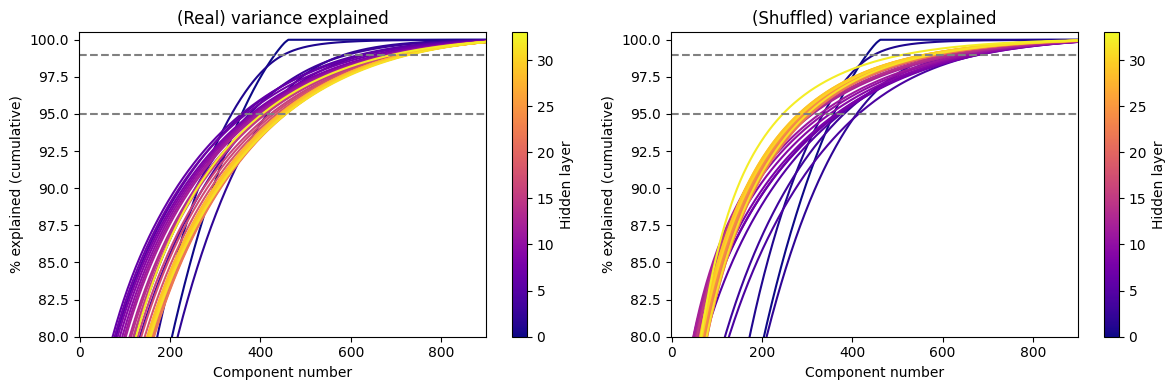

In [10]:
# setup the figure and axes
_,axs = plt.subplots(1,2,figsize=(12,4))

# normalization function for mapping layer index onto color
norm = mpl.colors.Normalize(vmin=0,vmax=num_hidden_layers)

# plt the cumulative variance explained
for layeri in range(num_hidden_layers):
  axs[0].plot(cum_var_explained[layeri,:,0],color=mpl.cm.plasma(norm(layeri)))
  axs[1].plot(cum_var_explained[layeri,:,1],color=mpl.cm.plasma(norm(layeri)))

for i in range(2):
  axs[i].axhline(95,linestyle='--',color='gray')
  axs[i].axhline(99,linestyle='--',color='gray')

# add colorbars
sm = mpl.cm.ScalarMappable(cmap=mpl.cm.plasma,norm=norm)
cbar = plt.colorbar(sm,ax=axs[0])
cbar.set_label(r'Hidden layer')
cbar = plt.colorbar(sm,ax=axs[1])
cbar.set_label(r'Hidden layer')

# make it look nicer
axs[0].set(xlabel='Component number',ylabel='% explained (cumulative)',ylim=[80,100.5],xlim=[-2,900],title='(Real) variance explained')
axs[1].set(xlabel='Component number',ylabel='% explained (cumulative)',ylim=[80,100.5],xlim=[-2,900],title='(Shuffled) variance explained')

plt.tight_layout()
plt.show()

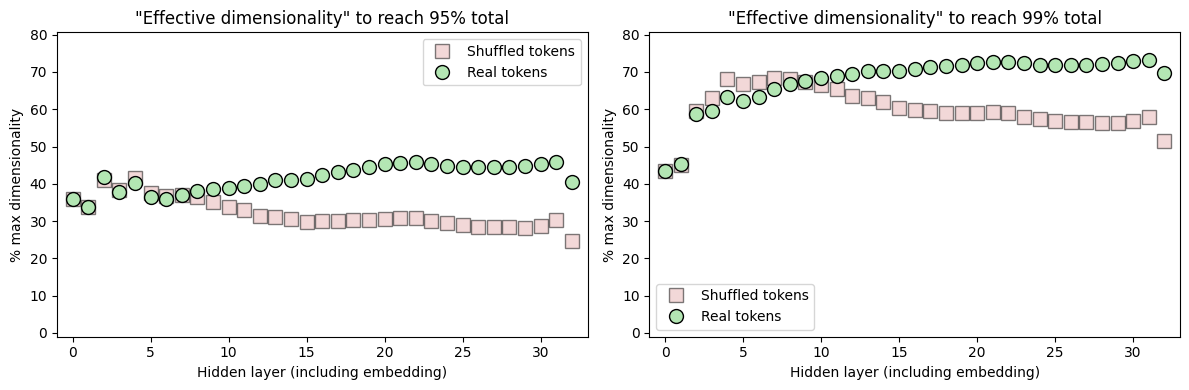

In [11]:
# convert to percent of total possible dimensionality
effectiveCompCountP = 100*effective_comp_count / len(s)

_,axs = plt.subplots(1,2,figsize=(12,4))

## plot the "effective subspace dimensionality" of the hidden layers
for i in range(2):
  axs[i].plot(effectiveCompCountP[:,1,i],'ks',markerfacecolor=[.9,.7,.7,.5],markersize=10,label='Shuffled tokens')
  axs[i].plot(effectiveCompCountP[:,0,i],'ko',markerfacecolor=[.7,.9,.7],markersize=10,label='Real tokens')
  axs[i].legend()
  axs[i].set(xlabel='Hidden layer (including embedding)',ylabel='% max dimensionality',
             title=f'"Effective dimensionality" to reach {[95,99][i]}% total',
             ylim=[-1,effectiveCompCountP.max()*1.1],xlim=[-1,num_hidden_layers])


plt.tight_layout()
plt.show()